# Model Evaluation and Improvement

Notebook ini membahas cara mengevaluasi dan meningkatkan model machine learning, terutama pada supervised learning. Fokus utama chapter ini adalah bagaimana mengukur kemampuan generalisasi model, memilih parameter terbaik, dan menggunakan metrik evaluasi yang sesuai dengan tujuan masalah.

Materi disusun dalam Bahasa Indonesia dengan penjelasan, contoh kode, visualisasi, dan analisis output.

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami pentingnya pemisahan data training dan testing.
- Menggunakan cross-validation untuk evaluasi model yang lebih stabil.
- Memahami beberapa strategi cross-validation seperti K-Fold, Stratified K-Fold, Leave-One-Out, ShuffleSplit, dan GroupKFold.
- Melakukan parameter tuning menggunakan Grid Search.
- Menghindari data leakage pada proses pemilihan model.
- Memahami metrik evaluasi klasifikasi seperti accuracy, confusion matrix, precision, recall, F1-score, dan ROC-AUC.
- Memahami metrik evaluasi regresi seperti R², MAE, dan MSE.
- Menggunakan scoring metric pada `cross_val_score` dan `GridSearchCV`.

## Persiapan Library

Library yang digunakan pada notebook ini berasal dari `numpy`, `pandas`, `matplotlib`, dan `scikit-learn`. Dataset yang digunakan berasal dari dataset bawaan scikit-learn dan data sintetis agar notebook dapat dijalankan langsung tanpa file tambahan.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, make_blobs, make_classification, make_regression
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    ShuffleSplit,
    GroupKFold,
    GridSearchCV
)
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

np.random.seed(42)
pd.set_option("display.max_columns", 100)

## Ringkasan Chapter

Evaluasi model merupakan proses untuk mengetahui apakah model machine learning mampu bekerja dengan baik pada data baru, bukan hanya pada data yang digunakan saat training. Model yang terlihat bagus pada data training belum tentu bagus pada data testing karena bisa saja mengalami overfitting.

Chapter ini membahas dua hal besar. Pertama, bagaimana mengevaluasi model menggunakan cross-validation dan metrik evaluasi yang tepat. Kedua, bagaimana meningkatkan model melalui pemilihan parameter menggunakan grid search.

Secara umum, alur kerja yang baik adalah:

| Tahap | Tujuan |
|---|---|
| Split data | Memisahkan data training dan testing |
| Cross-validation | Mengukur performa model dengan lebih stabil |
| Grid search | Mencari kombinasi parameter terbaik |
| Final evaluation | Mengevaluasi model akhir pada test set |
| Metric selection | Memilih ukuran performa yang sesuai dengan tujuan masalah |

## Training Set dan Test Set

Dalam supervised learning, model dilatih menggunakan data training dan diuji menggunakan data testing. Tujuan utamanya bukan hanya membuat model yang hafal data training, tetapi membuat model yang mampu melakukan generalisasi terhadap data baru.

Jika model hanya dievaluasi pada data training, hasilnya bisa terlalu optimis. Model mungkin terlihat sangat akurat karena sudah pernah melihat data tersebut. Oleh karena itu, test set harus disimpan sebagai data yang benar-benar belum dilihat model selama proses training.

Pada contoh berikut, dataset sintetis dibuat menggunakan `make_blobs`, lalu dibagi menjadi training set dan test set.

In [9]:
X, y = make_blobs(random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

train_score = logreg.score(X_train, y_train)
test_score = logreg.score(X_test, y_test)

print(f"Training score: {train_score:.2f}")
print(f"Test score: {test_score:.2f}")

Training score: 0.91
Test score: 0.88


## Analisis Training-Test Split

Nilai test score memberikan gambaran awal tentang kemampuan model terhadap data baru. Namun, hasil ini masih bergantung pada cara data dibagi. Jika pembagian data kebetulan mudah, score bisa terlihat tinggi. Sebaliknya, jika test set berisi data yang sulit, score bisa terlihat lebih rendah.

Karena itu, satu kali pembagian data belum selalu cukup untuk memberikan estimasi performa yang stabil. Untuk mengatasi hal ini, digunakan cross-validation.

## Cross-Validation

Cross-validation adalah metode evaluasi model dengan cara membagi data beberapa kali, kemudian melatih dan menguji model pada kombinasi data yang berbeda. Teknik yang paling umum digunakan adalah **k-fold cross-validation**.

Pada k-fold cross-validation, data dibagi menjadi `k` bagian. Model dilatih sebanyak `k` kali. Setiap kali, satu fold digunakan sebagai data validasi, sedangkan fold lainnya digunakan sebagai data training.

Contoh jika menggunakan 5-fold cross-validation:

| Iterasi | Training Fold | Validation Fold |
|---|---|---|
| 1 | Fold 2, 3, 4, 5 | Fold 1 |
| 2 | Fold 1, 3, 4, 5 | Fold 2 |
| 3 | Fold 1, 2, 4, 5 | Fold 3 |
| 4 | Fold 1, 2, 3, 5 | Fold 4 |
| 5 | Fold 1, 2, 3, 4 | Fold 5 |

Hasil akhirnya berupa beberapa nilai score, lalu biasanya diringkas menggunakan rata-rata.

In [10]:
iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

scores = cross_val_score(logreg, iris.data, iris.target, cv=5)

print("Cross-validation scores:", scores)
print(f"Average cross-validation score: {scores.mean():.2f}")
print(f"Standard deviation: {scores.std():.2f}")

Cross-validation scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Average cross-validation score: 0.97
Standard deviation: 0.02


## Analisis Cross-Validation

Cross-validation memberikan evaluasi yang lebih stabil dibandingkan satu kali training-test split. Selain rata-rata score, nilai standar deviasi juga penting. Jika standar deviasi tinggi, berarti performa model sangat bergantung pada pembagian data.

Keuntungan cross-validation:

| Keuntungan | Penjelasan |
|---|---|
| Lebih stabil | Evaluasi dilakukan pada beberapa split |
| Data digunakan lebih efektif | Setiap data pernah menjadi bagian training dan validasi |
| Memberi informasi variasi performa | Dapat melihat apakah model konsisten atau tidak |

Kekurangannya adalah waktu komputasi lebih lama karena model dilatih beberapa kali.

## Stratified K-Fold Cross-Validation

Pada klasifikasi, pembagian fold perlu menjaga proporsi kelas. Jika data tersusun berdasarkan label, K-Fold biasa bisa menghasilkan fold yang hanya berisi satu kelas tertentu. Hal ini dapat membuat evaluasi menjadi tidak valid.

**Stratified K-Fold** memastikan setiap fold memiliki distribusi kelas yang relatif sama dengan dataset asli. Teknik ini sangat berguna untuk dataset klasifikasi, terutama ketika data tidak seimbang.

In [11]:
y_iris = iris.target

print("Distribusi label iris:")
print(pd.Series(y_iris).value_counts().sort_index())

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(logreg, iris.data, iris.target, cv=skf)

print("\nStratified K-Fold scores:", scores_skf)
print(f"Mean score: {scores_skf.mean():.2f}")

Distribusi label iris:
0    50
1    50
2    50
Name: count, dtype: int64

Stratified K-Fold scores: [1.         0.96666667 0.93333333 1.         0.93333333]
Mean score: 0.97


## KFold dengan Shuffle

KFold biasa membagi data berdasarkan urutan. Jika data memiliki urutan tertentu, misalnya semua kelas 0 berada di awal, semua kelas 1 di tengah, dan semua kelas 2 di akhir, hasil evaluasi dapat bermasalah.

Salah satu solusi adalah menggunakan `shuffle=True`, sehingga data diacak sebelum dibagi menjadi fold.

In [12]:
kfold_no_shuffle = KFold(n_splits=3)
scores_no_shuffle = cross_val_score(logreg, iris.data, iris.target, cv=kfold_no_shuffle)

kfold_shuffle = KFold(n_splits=3, shuffle=True, random_state=0)
scores_shuffle = cross_val_score(logreg, iris.data, iris.target, cv=kfold_shuffle)

print("KFold tanpa shuffle:", scores_no_shuffle)
print("KFold dengan shuffle:", scores_shuffle)

KFold tanpa shuffle: [0. 0. 0.]
KFold dengan shuffle: [0.98 0.96 0.96]


## Leave-One-Out Cross-Validation

Leave-One-Out Cross-Validation atau LOOCV adalah bentuk khusus dari cross-validation, di mana setiap fold hanya berisi satu data sebagai test set. Jika dataset memiliki 150 data, maka model akan dilatih sebanyak 150 kali.

Metode ini dapat berguna untuk dataset kecil, tetapi sangat mahal secara komputasi untuk dataset besar.

In [13]:
loo = LeaveOneOut()

X_small = iris.data[:90]
y_small = iris.target[:90]

scores_loo = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_small,
    y_small,
    cv=loo
)

print("Jumlah iterasi LOOCV:", len(scores_loo))
print(f"Mean accuracy: {scores_loo.mean():.2f}")

Jumlah iterasi LOOCV: 90
Mean accuracy: 1.00


## ShuffleSplit Cross-Validation

ShuffleSplit melakukan pembagian data secara acak sebanyak beberapa iterasi. Berbeda dari K-Fold, jumlah iterasi dan ukuran data training/testing dapat diatur secara fleksibel.

Teknik ini cocok ketika peneliti ingin mengontrol ukuran training dan test set pada setiap iterasi.

In [14]:
shuffle_split = ShuffleSplit(
    n_splits=10,
    train_size=0.7,
    test_size=0.3,
    random_state=42
)

scores_shuffle_split = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)

print("ShuffleSplit scores:", scores_shuffle_split)
print(f"Mean score: {scores_shuffle_split.mean():.2f}")

ShuffleSplit scores: [1.         1.         0.91111111 0.95555556 0.93333333 0.97777778
 0.95555556 0.95555556 1.         0.91111111]
Mean score: 0.96


## GroupKFold

GroupKFold digunakan ketika dataset memiliki kelompok yang tidak boleh terpisah antara training dan testing. Contohnya pada data medis, satu pasien bisa memiliki beberapa sampel. Jika sampel dari pasien yang sama masuk ke training dan test set, evaluasi bisa terlalu optimis.

Dengan GroupKFold, seluruh data dari satu grup akan berada hanya di training atau hanya di testing pada setiap split.

In [15]:
X_group, y_group = make_blobs(n_samples=12, random_state=0)
groups = np.array([0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3])

group_kfold = GroupKFold(n_splits=3)

scores_group = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_group,
    y_group,
    groups=groups,
    cv=group_kfold
)

print("Groups:", groups)
print("GroupKFold scores:", scores_group)
print(f"Mean score: {scores_group.mean():.2f}")

Groups: [0 0 0 1 1 1 1 2 2 3 3 3]
GroupKFold scores: [0.75       0.6        0.66666667]
Mean score: 0.67


## Ringkasan Strategi Cross-Validation

| Strategi | Cocok Digunakan Ketika |
|---|---|
| KFold | Data umum, terutama regresi |
| StratifiedKFold | Klasifikasi dengan proporsi kelas yang perlu dijaga |
| LeaveOneOut | Dataset sangat kecil |
| ShuffleSplit | Ingin split acak dengan ukuran train-test tertentu |
| GroupKFold | Ada grup yang tidak boleh bocor ke train dan test sekaligus |

## Grid Search

Grid Search adalah metode untuk mencari kombinasi parameter terbaik dari sebuah model. Caranya adalah mencoba seluruh kombinasi parameter yang sudah ditentukan, kemudian memilih kombinasi dengan performa terbaik.

Contohnya pada model SVC dengan kernel RBF, parameter penting yang sering dicari adalah:

| Parameter | Fungsi |
|---|---|
| C | Mengatur kekuatan regularisasi |
| gamma | Mengatur jangkauan pengaruh setiap data point |

Semakin banyak kombinasi parameter, semakin lama proses grid search berjalan.

In [16]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

best_score = 0
best_parameters = {}

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        score = svm.score(X_test, y_test)

        if score > best_score:
            best_score = score
            best_parameters = {"C": C, "gamma": gamma}

print(f"Best score: {best_score:.2f}")
print("Best parameters:", best_parameters)

Best score: 0.97
Best parameters: {'C': 100, 'gamma': 0.001}


## Bahaya Overfitting pada Test Set

Contoh grid search manual di atas terlihat sederhana, tetapi memiliki masalah penting. Parameter dipilih berdasarkan performa pada test set. Artinya, test set tidak lagi benar-benar independen karena sudah digunakan dalam proses pemilihan model.

Jika test set digunakan untuk memilih parameter, hasil evaluasi akhir bisa terlalu optimis. Praktik yang lebih benar adalah membagi data menjadi:

| Dataset | Fungsi |
|---|---|
| Training set | Melatih model |
| Validation set | Memilih parameter |
| Test set | Evaluasi akhir model |

In [17]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, random_state=1
)

best_score = 0
best_parameters = {}

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        score = svm.score(X_valid, y_valid)

        if score > best_score:
            best_score = score
            best_parameters = {"C": C, "gamma": gamma}

final_model = SVC(**best_parameters)
final_model.fit(X_trainval, y_trainval)
test_score = final_model.score(X_test, y_test)

print("Ukuran training set:", X_train.shape[0])
print("Ukuran validation set:", X_valid.shape[0])
print("Ukuran test set:", X_test.shape[0])
print(f"Best validation score: {best_score:.2f}")
print("Best parameters:", best_parameters)
print(f"Final test score: {test_score:.2f}")

Ukuran training set: 84
Ukuran validation set: 28
Ukuran test set: 38
Best validation score: 0.96
Best parameters: {'C': 10, 'gamma': 0.001}
Final test score: 0.92


## Grid Search dengan Cross-Validation

Pendekatan yang lebih stabil adalah menggabungkan grid search dengan cross-validation. Setiap kombinasi parameter dievaluasi menggunakan cross-validation pada training set. Setelah parameter terbaik ditemukan, model akhir dilatih menggunakan seluruh training set dan dievaluasi pada test set.

Di scikit-learn, proses ini dapat dilakukan dengan `GridSearchCV`.

In [18]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5
)

grid_search.fit(X_trainval, y_trainval)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.2f}")
print(f"Test set score: {grid_search.score(X_test, y_test):.2f}")

Best parameters: {'C': 10, 'gamma': 0.1}
Best cross-validation score: 0.97
Test set score: 0.97


## Analisis Hasil Grid Search

`best_score_` menunjukkan rata-rata performa cross-validation terbaik pada training set. Nilai ini bukan performa final pada test set. Performa final tetap harus dilihat dari `score(X_test, y_test)`.

Atribut penting dari `GridSearchCV`:

| Atribut | Fungsi |
|---|---|
| `best_params_` | Kombinasi parameter terbaik |
| `best_score_` | Rata-rata score cross-validation terbaik |
| `best_estimator_` | Model terbaik yang sudah dilatih ulang |
| `cv_results_` | Detail hasil seluruh kombinasi parameter |

In [19]:
results = pd.DataFrame(grid_search.cv_results_)

results[[
    "param_C",
    "param_gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_C,param_gamma,mean_test_score,std_test_score,rank_test_score
26,10.0,0.100,0.973123,0.021957,1
31,100.0,0.010,0.964427,0.032761,2
30,100.0,0.001,0.964032,0.033918,3
20,1.0,0.100,0.964032,0.033918,3
25,10.0,0.010,0.964032,0.033918,3
15,0.1,1.000,0.955336,0.039794,6
32,100.0,0.100,0.954941,0.049799,7
21,1.0,1.000,0.946640,0.033305,8
33,100.0,1.000,0.946245,0.044708,9
27,10.0,1.000,0.946245,0.044708,9


## Visualisasi Hasil Grid Search

Heatmap dapat membantu melihat bagaimana perubahan parameter memengaruhi performa model. Area dengan score tinggi menunjukkan kombinasi parameter yang baik.

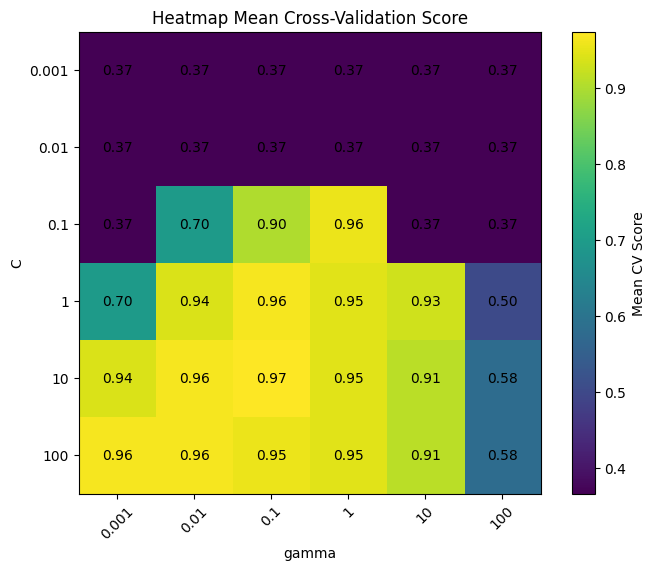

In [20]:
scores = results["mean_test_score"].values.reshape(6, 6)

plt.figure(figsize=(8, 6))
plt.imshow(scores, interpolation="nearest")
plt.xlabel("gamma")
plt.ylabel("C")
plt.colorbar(label="Mean CV Score")
plt.xticks(np.arange(len(param_grid["gamma"])), param_grid["gamma"], rotation=45)
plt.yticks(np.arange(len(param_grid["C"])), param_grid["C"])

for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        plt.text(j, i, f"{scores[i, j]:.2f}", ha="center", va="center")

plt.title("Heatmap Mean Cross-Validation Score")
plt.show()

## Search Space yang Tidak Selalu Berbentuk Grid Tunggal

Tidak semua parameter relevan untuk semua kondisi model. Misalnya pada SVC:

- Jika `kernel='linear'`, parameter `gamma` tidak digunakan.
- Jika `kernel='rbf'`, parameter `gamma` digunakan.

Untuk kondisi seperti ini, `param_grid` dapat dibuat sebagai list of dictionaries.

In [21]:
param_grid_conditional = [
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": [0.001, 0.01, 0.1, 1]
    },
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100]
    }
]

grid_search_conditional = GridSearchCV(
    SVC(),
    param_grid_conditional,
    cv=5
)

grid_search_conditional.fit(X_trainval, y_trainval)

print("Best parameters:", grid_search_conditional.best_params_)
print(f"Best CV score: {grid_search_conditional.best_score_:.2f}")
print(f"Test score: {grid_search_conditional.score(X_test, y_test):.2f}")

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV score: 0.97
Test score: 0.97


## Nested Cross-Validation

Nested cross-validation digunakan untuk mengevaluasi proses pemilihan model secara lebih ketat. Ada dua loop:

- Inner loop: mencari parameter terbaik.
- Outer loop: mengevaluasi performa generalisasi.

Nested cross-validation biasanya digunakan untuk evaluasi yang sangat hati-hati, bukan untuk menghasilkan satu model final. Kekurangannya adalah biaya komputasi tinggi karena model dilatih berkali-kali.

In [22]:
nested_scores = cross_val_score(
    GridSearchCV(SVC(), param_grid, cv=5),
    iris.data,
    iris.target,
    cv=5
)

print("Nested CV scores:", nested_scores)
print(f"Mean nested CV score: {nested_scores.mean():.2f}")

Nested CV scores: [0.96666667 1.         0.96666667 0.96666667 1.        ]
Mean nested CV score: 0.98


## Evaluation Metrics dan Scoring

Accuracy bukan satu-satunya metrik evaluasi. Dalam banyak kasus, accuracy bisa menyesatkan, terutama pada dataset yang tidak seimbang. Misalnya, jika 95% data adalah kelas negatif, model yang selalu menebak negatif bisa mendapatkan accuracy 95%, tetapi sebenarnya tidak berguna untuk mendeteksi kelas positif.

Pemilihan metrik harus disesuaikan dengan tujuan akhir. Pada kasus medis, recall mungkin lebih penting karena kesalahan melewatkan pasien sakit bisa berbahaya. Pada kasus spam detection, precision juga penting agar email penting tidak salah masuk spam.

## Confusion Matrix

Confusion matrix menunjukkan jumlah prediksi benar dan salah untuk setiap kelas.

Untuk klasifikasi biner:

| Istilah | Makna |
|---|---|
| True Positive (TP) | Data positif diprediksi positif |
| True Negative (TN) | Data negatif diprediksi negatif |
| False Positive (FP) | Data negatif salah diprediksi positif |
| False Negative (FN) | Data positif salah diprediksi negatif |

In [23]:
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=42
)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual malignant", "Actual benign"],
    columns=["Predicted malignant", "Predicted benign"]
)

cm_df

,Predicted malignant,Predicted benign
Actual malignant,48,5
Actual benign,1,89


## Precision, Recall, dan F1-Score

Beberapa metrik yang sering digunakan pada klasifikasi biner adalah:

| Metrik | Fokus |
|---|---|
| Precision | Seberapa banyak prediksi positif yang benar-benar positif |
| Recall | Seberapa banyak data positif yang berhasil ditemukan |
| F1-score | Rata-rata harmonik antara precision dan recall |

Precision penting ketika false positive harus ditekan. Recall penting ketika false negative harus ditekan. F1-score berguna ketika ingin menyeimbangkan precision dan recall.

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Accuracy: 0.958041958041958
Precision: 0.9468085106382979
Recall: 0.9888888888888889
F1-score: 0.967391304347826

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



## ROC Curve dan AUC

ROC Curve menggambarkan hubungan antara True Positive Rate dan False Positive Rate pada berbagai threshold. AUC atau Area Under Curve merangkum performa model dalam satu nilai.

Nilai AUC mendekati 1 menunjukkan model mampu membedakan kelas positif dan negatif dengan baik. Nilai sekitar 0.5 menunjukkan performa mendekati tebakan acak.

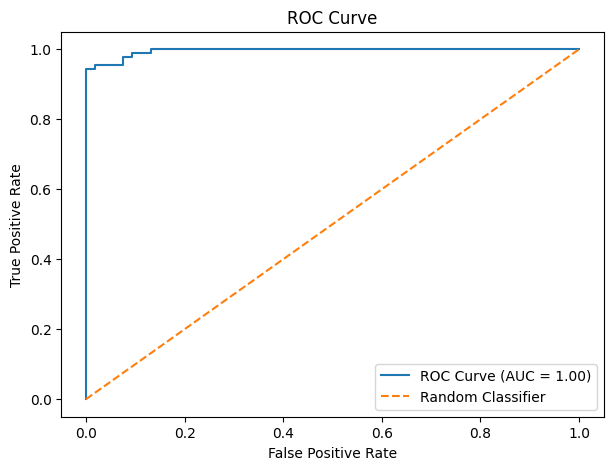

In [25]:
y_score = clf.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Pengaruh Class Imbalance terhadap Accuracy

Contoh berikut menunjukkan mengapa accuracy dapat menyesatkan pada data tidak seimbang. Dataset dibuat dengan 95% data pada kelas 0 dan hanya 5% pada kelas 1.

In [26]:
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=3,
    n_redundant=2,
    weights=[0.95, 0.05],
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imb, stratify=y_imb, random_state=42
)

dummy_pred = np.zeros_like(y_test)

print("Distribusi kelas test:")
print(pd.Series(y_test).value_counts(normalize=True))

print("\nModel yang selalu prediksi kelas 0")
print("Accuracy:", accuracy_score(y_test, dummy_pred))
print("Precision:", precision_score(y_test, dummy_pred, zero_division=0))
print("Recall:", recall_score(y_test, dummy_pred))
print("F1-score:", f1_score(y_test, dummy_pred))

Distribusi kelas test:
0    0.944
1    0.056
Name: proportion, dtype: float64

Model yang selalu prediksi kelas 0
Accuracy: 0.944
Precision: 0.0
Recall: 0.0
F1-score: 0.0


## Analisis Class Imbalance

Model yang selalu memprediksi kelas mayoritas bisa memperoleh accuracy tinggi, tetapi precision, recall, dan F1-score untuk kelas minoritas bernilai buruk. Hal ini menunjukkan bahwa accuracy tidak cukup untuk mengevaluasi model pada dataset tidak seimbang.

Dalam kondisi seperti ini, metrik seperti recall, precision, F1-score, ROC-AUC, atau PR-AUC perlu dipertimbangkan.

## Evaluation Metrics untuk Regression

Pada regresi, target berupa nilai kontinu. Metrik yang umum digunakan adalah:

| Metrik | Penjelasan |
|---|---|
| MAE | Rata-rata kesalahan absolut |
| MSE | Rata-rata kuadrat kesalahan |
| RMSE | Akar dari MSE, kembali ke satuan target |
| R² | Proporsi variasi target yang dapat dijelaskan model |

MAE lebih mudah diinterpretasikan karena satuannya sama dengan target. MSE/RMSE lebih sensitif terhadap error besar. R² berguna untuk melihat kualitas model secara umum, tetapi perlu hati-hati jika data memiliki pola kompleks.

In [27]:
X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=5,
    noise=20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_reg = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [mae, mse, rmse, r2]
})

,Metric,Value
0,MAE,14.719496
1,MSE,373.077744
2,RMSE,19.315221
3,R2,0.968722


## Scoring pada Cross-Validation

`cross_val_score` secara default menggunakan metode `score()` dari model. Untuk klasifikasi biasanya accuracy, sedangkan untuk regresi biasanya R². Namun, kita dapat menentukan metrik lain menggunakan parameter `scoring`.

Contoh berikut membandingkan accuracy, F1, dan ROC-AUC pada dataset klasifikasi biner.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=42
)

model = LogisticRegression(max_iter=5000)

accuracy_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
f1_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
roc_auc_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")

pd.DataFrame({
    "Metric": ["Accuracy", "F1", "ROC-AUC"],
    "Mean CV Score": [
        accuracy_scores.mean(),
        f1_scores.mean(),
        roc_auc_scores.mean()
    ],
    "Std": [
        accuracy_scores.std(),
        f1_scores.std(),
        roc_auc_scores.std()
    ]
})

,Metric,Mean CV Score,Std
0,Accuracy,0.948317,0.016044
1,F1,0.959251,0.012586
2,ROC-AUC,0.989736,0.010154


## Grid Search dengan Scoring Metric Tertentu

Pada `GridSearchCV`, parameter terbaik dipilih berdasarkan metrik yang digunakan. Jika kita menggunakan `scoring='recall'`, maka grid search akan memilih model yang paling baik dalam menemukan kelas positif, bukan sekadar yang accuracy-nya paling tinggi.

Pemilihan scoring harus disesuaikan dengan tujuan masalah.

In [29]:
param_grid_lr = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_recall = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid_lr,
    cv=5,
    scoring="recall"
)

grid_recall.fit(X_train, y_train)

print("Best parameters based on recall:", grid_recall.best_params_)
print(f"Best CV recall: {grid_recall.best_score_:.3f}")
print(f"Test recall: {recall_score(y_test, grid_recall.predict(X_test)):.3f}")

c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/p

Best parameters based on recall: {'C': 1}
Best CV recall: 0.970
Test recall: 0.989


## Ringkasan Akhir Chapter

Chapter ini menunjukkan bahwa evaluasi model tidak boleh dilakukan secara sembarangan. Model harus diuji berdasarkan kemampuan generalisasi terhadap data baru, bukan hanya performa pada data training.

Poin penting dari chapter ini:

- Training-test split digunakan untuk mengevaluasi model pada data yang belum dilihat.
- Cross-validation memberikan estimasi performa yang lebih stabil.
- Stratified K-Fold penting untuk klasifikasi agar proporsi kelas tetap terjaga.
- GroupKFold digunakan untuk mencegah data leakage antargrup.
- Grid Search membantu mencari parameter terbaik.
- Test set tidak boleh digunakan untuk memilih parameter.
- Nested cross-validation memberikan evaluasi yang lebih ketat, tetapi mahal secara komputasi.
- Accuracy tidak selalu cukup, terutama untuk dataset tidak seimbang.
- Precision, recall, F1-score, ROC-AUC, MAE, MSE, RMSE, dan R² perlu dipilih sesuai tujuan masalah.

Secara keseluruhan, evaluasi model yang baik bukan hanya mencari angka score tertinggi, tetapi memilih metrik dan prosedur evaluasi yang sesuai dengan tujuan akhir penggunaan model.